# Imports + Config

In [1]:
# Install dependencies
!pip -q install requests beautifulsoup4 lxml tqdm pandas yfinance

# Imports
import os
import re
import json
import time
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta, timezone
from urllib.parse import urljoin, urlparse, urlunparse

import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import yfinance as yf

import matplotlib.pyplot as plt


# Config (paths + limits)
BASE_DIR = "."
COMPANIES_CSV = os.path.join(BASE_DIR, "companies.csv")

OUT_FDA_JSONL   = os.path.join(BASE_DIR, "data", "regulatory", "fda_docs.jsonl")
OUT_GDELT_JSONL = os.path.join(BASE_DIR, "data", "news", "gdelt_articles.jsonl")
OUT_YF_DIR      = os.path.join(BASE_DIR, "data", "financial", "yahoo")

OUT_GDELT_FAILURES_JSON = os.path.join(BASE_DIR, "data", "news", "gdelt_articles_failures.json")
OUT_NEWS_CLEAN_JSONL = os.path.join(BASE_DIR, "data", "news", "news_articles_clean.jsonl")
OUT_NEWS_DEDUP_JSONL = os.path.join(BASE_DIR, "data", "news", "news_articles_dedup.jsonl")
OUT_KG_EDGES_JSONL = os.path.join(BASE_DIR, "data", "kg", "kg_edges.jsonl")
OUT_KG_NODES_JSONL = os.path.join(BASE_DIR, "data", "kg", "kg_nodes.jsonl")
OUT_MASTER_JSONL = os.path.join(BASE_DIR, "data", "master", "master_records.jsonl")


os.makedirs(os.path.dirname(OUT_FDA_JSONL), exist_ok=True)
os.makedirs(os.path.dirname(OUT_GDELT_JSONL), exist_ok=True)
os.makedirs(OUT_YF_DIR, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "data", "kg"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "data", "master"), exist_ok=True)

# Run controls
FDA_MAX_PAGES = 200
FDA_MIN_RELEVANCE = 3
FDA_DELAY_S = 1.0

# GDELT CONFIG
GDELT_DAYS_BACK = 14
GDELT_DELAY_S = 15.0 # slower to reduce rate limit issues
GDELT_MAXRECORDS = 25  
GDELT_RETRIES = 3
GDELT_RETRY_BASE_SLEEP = 20 

YF_PERIOD = "5y"


# Load companies + build alias list

In [2]:
companies_df = pd.read_csv(COMPANIES_CSV)

def build_aliases(df: pd.DataFrame) -> list[str]:
    aliases = []
    for _, row in df.iterrows():
        aliases.append(str(row.get("company_name","")).strip())
        aliases.append(str(row.get("ticker","")).strip())
        extra = str(row.get("aliases","")).strip()
        if extra:
            aliases.extend([a.strip() for a in extra.split(";") if a.strip()])
    seen, out = set(), []
    for a in aliases:
        if a and a not in seen:
            out.append(a)
            seen.add(a)
    return out

COMPANY_ALIASES = build_aliases(companies_df)
len(COMPANY_ALIASES), COMPANY_ALIASES[:10]


def build_gdelt_query(name, ticker=None, aliases=None):
    """
    Final stable GDELT query builder.
    Uses company name + alias only.
    Avoids tickers (main source of problems).
    """

    terms = []

    # Main company name
    if pd.notna(name) and str(name).strip():
        terms.append(f'"{str(name).strip()}"')

    # One alias max (avoid complex OR chains)
    if aliases is not None and pd.notna(aliases):
        alias_list = [a.strip() for a in str(aliases).split(";") if a.strip()]

        if alias_list:
            alias = alias_list[0]

            # Avoid too-short alias phrases
            if len(alias) >= 4:
                terms.append(f'"{alias}"')

    if not terms:
        raise ValueError("No valid GDELT search terms")

    if len(terms) == 1:
        entity_clause = terms[0]
    else:
        entity_clause = "(" + " OR ".join(terms) + ")"

    topic_clause = "(health OR FDA OR drug OR device OR recall OR approval)"

    return f"{entity_clause} AND {topic_clause}"


# Helper functions

In [3]:
def now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def normalize_ws(text: str) -> str:
    return re.sub(r"\s+", " ", (text or "")).strip()

def normalize_url(url: str) -> str:
    # Drop fragments, normalize trailing slashes, normalize netloc casing.
    p = urlparse(url)
    p = p._replace(fragment="", netloc=p.netloc.lower())
    path = p.path or "/"
    if path != "/" and path.endswith("/"):
        path = path[:-1]
    p = p._replace(path=path)
    return urlunparse(p)

def safe_makedirs_for_file(path: str):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)


# Crawler 1: FDA focused crawler (JSONL)

In [4]:
FDA_ALLOWED_DOMAINS = {"www.fda.gov", "fda.gov"}

FDA_SEEDS = [
    "https://www.fda.gov/safety/recalls-market-withdrawals-safety-alerts",
    "https://www.fda.gov/drugs/drug-safety-and-availability",
    "https://www.fda.gov/news-events/fda-newsroom/press-announcements",]

FDA_KEYWORDS = [
    "recall", "warning letter", "safety", "adverse", "labeling", "approval", "enforcement",
    "market withdrawal", "alert", "communication", "inspection",]

def fda_is_allowed(url: str) -> bool:
    try:
        host = urlparse(url).netloc.lower()
        return host in FDA_ALLOWED_DOMAINS or host.endswith(".fda.gov")
    except Exception:
        return False

def fda_relevance_score(text: str, url: str = "") -> int:
    t = (text or "").lower()
    u = (url or "").lower()
    score = 0
    for kw in FDA_KEYWORDS:
        if kw in t:
            score += 2
        if kw.replace(" ", "-") in u or kw.replace(" ", "") in u:
            score += 1
    return score

def fda_extract_main_text(html: str) -> str:
    soup = BeautifulSoup(html, "lxml")
    for tag in soup(["script", "style", "noscript", "header", "footer", "nav", "aside"]):
        tag.decompose()
    main = soup.find("main") or soup.find("article")
    text = main.get_text(separator=" ", strip=True) if main else soup.get_text(separator=" ", strip=True)
    return normalize_ws(text)

def fda_extract_title(html: str) -> str:
    soup = BeautifulSoup(html, "lxml")
    if soup.title and soup.title.text:
        return normalize_ws(soup.title.text)
    h1 = soup.find("h1")
    return normalize_ws(h1.get_text(strip=True)) if h1 else ""

def fda_extract_links(html: str, base_url: str) -> list[str]:
    soup = BeautifulSoup(html, "lxml")
    links = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if href.startswith("#") or href.lower().startswith("javascript:"):
            continue
        abs_url = normalize_url(urljoin(base_url, href))
        if fda_is_allowed(abs_url):
            links.append(abs_url)
    return links

def lightweight_mentions(text: str, company_aliases: list[str]) -> list[str]:
    t = text or ""
    hits = []
    for alias in company_aliases:
        a = alias.strip()
        if not a:
            continue
        if a.isupper() and 1 < len(a) <= 5:
            pattern = rf"\b{re.escape(a)}\b"
            if re.search(pattern, t):  # case-sensitive
                hits.append(a)
        else:
            pattern = rf"\b{re.escape(a)}\b"
            if re.search(pattern, t, flags=re.IGNORECASE):
                hits.append(a)

    # de-dupe preserving order
    seen, out = set(), []
    for h in hits:
        if h not in seen:
            out.append(h)
            seen.add(h)
    return out

def fda_fetch(session: requests.Session, url: str, timeout: int = 20) -> tuple[str|None, int|None, str]:
    headers = {
        "User-Agent": "MSDS459-KG-Crawler/1.0 (educational)",
        "Accept-Language": "en-US,en;q=0.9",
    }
    try:
        r = session.get(url, headers=headers, timeout=timeout)
        status = r.status_code
        final_url = normalize_url(r.url)
        if status != 200:
            return None, status, final_url
        ctype = (r.headers.get("Content-Type") or "").lower()
        if "text/html" not in ctype:
            return None, status, final_url
        return r.text, status, final_url
    except requests.RequestException:
        return None, None, normalize_url(url)

@dataclass
class FDADoc:
    source: str
    url: str
    fetched_at: str
    http_status: int|None
    title: str
    text: str
    relevance: int
    mentions: list[str]

def run_fda_crawler(
    out_jsonl: str,
    seeds: list[str] = FDA_SEEDS,
    max_pages: int = 200,
    min_relevance: int = 3,
    delay_s: float = 1.0,
    company_aliases: list[str] = None
) -> None:
    safe_makedirs_for_file(out_jsonl)
    company_aliases = company_aliases or []

    seen = set()
    frontier = [normalize_url(s) for s in seeds]
    frontier_set = set(frontier)

    wrote = 0

    with requests.Session() as session, open(out_jsonl, "w", encoding="utf-8") as f:
        for _ in tqdm(range(max_pages), desc="FDA Crawl"):
            if not frontier:
                break

            frontier.sort(key=lambda u: fda_relevance_score("", u), reverse=True)
            url = frontier.pop(0)
            frontier_set.discard(url)

            if url in seen:
                continue
            seen.add(url)

            html, status, final_url = fda_fetch(session, url)
            time.sleep(delay_s)

            if not html:
                continue

            title = fda_extract_title(html)
            text = fda_extract_main_text(html)
            rel = fda_relevance_score(text, final_url)

            if rel >= min_relevance and len(text) > 400:
                mentions = lightweight_mentions(text, company_aliases)
                rec = FDADoc(
                    source="FDA",
                    url=final_url,
                    fetched_at=now_iso(),
                    http_status=status,
                    title=title,
                    text=text,
                    relevance=rel,
                    mentions=mentions,
                )
                f.write(json.dumps(asdict(rec), ensure_ascii=False) + "\n")
                wrote += 1

            for link in fda_extract_links(html, final_url):
                if link not in seen and link not in frontier_set and len(frontier) < max_pages * 10:
                    frontier.append(link)
                    frontier_set.add(link)

    print(f"FDA done. Wrote {wrote} docs to {out_jsonl}. Visited {len(seen)} pages.")


# Crawler 2: GDELT collector (JSONL)

In [5]:
def gdelt_fetch(query, start_dt, end_dt, maxrecords=25, retries=3, base_sleep=15):
    """
    Fetch GDELT DOC API results safely.
    Handles:
    - empty responses
    - HTML/text error pages
    - JSON decode failures
    - 429 Too Many Requests
    """
    url = "https://api.gdeltproject.org/api/v2/doc/doc"

    params = {
        "query": query,
        "mode": "ArtList",
        "format": "json",
        "maxrecords": int(maxrecords),
        "startdatetime": start_dt.strftime("%Y%m%d%H%M%S"),
        "enddatetime": end_dt.strftime("%Y%m%d%H%M%S"),
        "sort": "DateDesc",
    }

    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; FDA-Crawler/1.0)"
    }

    last_error = None

    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=30)

            content_type = (r.headers.get("Content-Type") or "").lower()
            text = (r.text or "").strip()

            print(f"[GDELT] attempt={attempt} status={r.status_code} content_type={content_type}")

            if r.status_code == 429:
                raise requests.HTTPError(f"429 Too Many Requests for url: {r.url}")

            r.raise_for_status()

            if not text:
                raise ValueError("Empty response body from GDELT")

            # If GDELT sends back HTML or plain text error instead of JSON
            if ("text/html" in content_type or "text/plain" in content_type) and not text.startswith("{"):
                preview = text[:500]
                raise ValueError(f"Non-JSON response from GDELT. First 500 chars:\n{preview}")

            try:
                data = r.json()
            except Exception:
                preview = text[:500]
                raise ValueError(f"JSON parse failed. First 500 chars:\n{preview}")

            if not isinstance(data, dict):
                raise ValueError("Unexpected GDELT JSON structure")

            return data

        except Exception as e:
            last_error = e
            print(f"[GDELT] attempt {attempt} failed: {e}")

            if attempt < retries:
                sleep_for = base_sleep * attempt
                print(f"[GDELT] sleeping {sleep_for}s before retry")
                time.sleep(sleep_for)

    raise RuntimeError(f"GDELT request failed after {retries} attempts: {last_error}")
    

def run_gdelt_collector(
    companies_df: pd.DataFrame,
    out_jsonl: str,
    days_back: int = 14,
    delay_s: float = 12.0,
    maxrecords: int = 25
):
    safe_makedirs_for_file(out_jsonl)

    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(days=days_back)

    wrote = 0
    failures = []

    with open(out_jsonl, "w", encoding="utf-8") as f:
        for _, row in tqdm(companies_df.iterrows(), total=len(companies_df), desc="GDELT"):
            name = str(row.get("company_name", "")).strip()
            ticker = str(row.get("ticker", "")).strip()
            aliases = row.get("aliases", "")

            try:
                q = build_gdelt_query(name=name, ticker=ticker, aliases=aliases)

                data = gdelt_fetch(
                    query=q,
                    start_dt=start_dt,
                    end_dt=end_dt,
                    maxrecords=maxrecords,
                    retries=GDELT_RETRIES,
                    base_sleep=GDELT_RETRY_BASE_SLEEP
                )

                articles = data.get("articles", [])
                print(f"[GDELT] {name} ({ticker}) -> {len(articles)} articles")

                for a in articles:
                    rec = {
                        "source": "GDELT",
                        "company": name,
                        "ticker": ticker,
                        "query": q,
                        "fetched_at": now_iso(),
                        "url": a.get("url"),
                        "title": a.get("title"),
                        "seendate": a.get("seendate"),
                        "domain": a.get("domain"),
                        "language": a.get("language"),
                        "sourcecountry": a.get("sourcecountry") or a.get("sourceCountry"),
                        "tone": a.get("tone"),
                    }
                    f.write(json.dumps(rec, ensure_ascii=False) + "\n")
                    wrote += 1

            except Exception as e:
                print(f"[GDELT] Failed for {name} ({ticker}): {e}")
                failures.append({
                    "company": name,
                    "ticker": ticker,
                    "error": str(e)
                })

            time.sleep(delay_s)

    print(f"GDELT done. Wrote {wrote} records to {out_jsonl}.")
    print(f"GDELT failures: {len(failures)}")

    if failures:
        fail_path = out_jsonl.replace(".jsonl", "_failures.json")
        with open(fail_path, "w", encoding="utf-8") as ff:
            json.dump(failures, ff, ensure_ascii=False, indent=2)
        print(f"Saved failures to {fail_path}")


In [6]:
# Test

# Quick single-company test
test_name = companies_df.iloc[0]["company_name"]
test_ticker = companies_df.iloc[0]["ticker"]
test_aliases = companies_df.iloc[0]["aliases"] if "aliases" in companies_df.columns else ""

test_end_dt = datetime.now(timezone.utc)
test_start_dt = test_end_dt - timedelta(days=GDELT_DAYS_BACK)

test_query = build_gdelt_query(
    name=test_name,
    ticker=test_ticker,
    aliases=test_aliases
)

print("TEST QUERY:", test_query)

test_data = gdelt_fetch(
    query=test_query,
    start_dt=test_start_dt,
    end_dt=test_end_dt,
    maxrecords=10,
    retries=GDELT_RETRIES,
    base_sleep=GDELT_RETRY_BASE_SLEEP
)

print("Returned keys:", test_data.keys())
print("Article count:", len(test_data.get("articles", [])))

TEST QUERY: ("Pfizer Inc." OR "Pfizer") AND (health OR FDA OR drug OR device OR recall OR approval)
[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22Pfizer+Inc.%22+OR+%22Pfizer%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=10&startdatetime=20260222210908&enddatetime=20260308210908&sort=DateDesc
[GDELT] sleeping 20s before retry
[GDELT] attempt=2 status=429 content_type=
[GDELT] attempt 2 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22Pfizer+Inc.%22+OR+%22Pfizer%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=10&startdatetime=20260222210908&enddatetime=20260308210908&sort=DateDesc
[GDELT] sleeping 40s before retry
[GDELT] attempt=3 status=200 content_type=application/json; charset=utf-8
Returned keys: dict_keys(['artic

# Crawler 3: Yahoo Finance time series (CSV)

In [7]:
def run_yahoo_finance_downloader(
    companies_df: pd.DataFrame,
    out_dir: str,
    period: str = "5y"
) -> pd.DataFrame:
    os.makedirs(out_dir, exist_ok=True)

    summary = []
    for tkr in tqdm(companies_df["ticker"].tolist(), desc="Yahoo Finance"):
        df = yf.download(tkr, period=period, interval="1d", progress=False)
        df = df.reset_index()

        out_path = os.path.join(out_dir, f"{tkr}.csv")
        df.to_csv(out_path, index=False)

        summary.append({
            "ticker": tkr,
            "rows": len(df),
            "start": str(df["Date"].min()) if len(df) else None,
            "end": str(df["Date"].max()) if len(df) else None
        })

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
    print(f"Yahoo Finance done. Saved CSVs to {out_dir}")
    return summary_df


# Run Crawlers

In [8]:
# FDA
run_fda_crawler(
    out_jsonl=OUT_FDA_JSONL,
    max_pages=FDA_MAX_PAGES,
    min_relevance=FDA_MIN_RELEVANCE,
    delay_s=FDA_DELAY_S,
    company_aliases=COMPANY_ALIASES)


# Yahoo Finance
yf_summary = run_yahoo_finance_downloader(
    companies_df=companies_df,
    out_dir=OUT_YF_DIR,
    period=YF_PERIOD)
yf_summary.head()


# GDELT
run_gdelt_collector(
    companies_df=companies_df,
    out_jsonl=OUT_GDELT_JSONL,
    days_back=GDELT_DAYS_BACK,
    delay_s=GDELT_DELAY_S,
    maxrecords=GDELT_MAXRECORDS)

FDA Crawl: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [04:34<00:00,  1.37s/it]


FDA done. Wrote 195 docs to ./data/regulatory/fda_docs.jsonl. Visited 200 pages.


Yahoo Finance: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:27<00:00,  1.54s/it]


Yahoo Finance done. Saved CSVs to ./data/financial/yahoo


GDELT:   0%|                                                                                                                                                          | 0/18 [00:00<?, ?it/s]

...

[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%22CVS+Health+Corporation%22+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=25&startdatetime=20260222211520&enddatetime=20260308211520&sort=DateDesc
[GDELT] sleeping 20s before retry
[GDELT] attempt=2 status=429 content_type=
[GDELT] attempt 2 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%22CVS+Health+Corporation%22+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=25&startdatetime=20260222211520&enddatetime=20260308211520&sort=DateDesc
[GDELT] sleeping 40s before retry
[GDELT] attempt=3 status=429 content_type=
[GDELT] attempt 3 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%22CVS+Health+Corporation%22+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+

GDELT:  94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉        | 17/18 [15:48<01:00, 60.50s/it]

[GDELT] attempt=1 status=429 content_type=
[GDELT] attempt 1 failed: 429 Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22The+Cigna+Group%22+OR+%22Cigna%22%29+AND+%28health+OR+FDA+OR+drug+OR+device+OR+recall+OR+approval%29&mode=ArtList&format=json&maxrecords=25&startdatetime=20260222211520&enddatetime=20260308211520&sort=DateDesc
[GDELT] sleeping 20s before retry
[GDELT] attempt=2 status=200 content_type=application/json; charset=utf-8
[GDELT] The Cigna Group (CI) -> 25 articles


GDELT: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [16:28<00:00, 54.93s/it]

GDELT done. Wrote 273 records to ./data/news/gdelt_articles.jsonl.
GDELT failures: 7
Saved failures to ./data/news/gdelt_articles_failures.json


# Data Check (FDA)

In [9]:
def read_jsonl(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

fda_df = read_jsonl(OUT_FDA_JSONL)
fda_df[["title","url","relevance","mentions"]].head(10)


,title,url,relevance,mentions
0,"Recalls, Market Withdrawals, & Safety Alerts |...",https://www.fda.gov/safety/recalls-market-with...,12,[]
1,Enforcement Reports | FDA,https://www.fda.gov/safety/recalls-market-with...,15,[]
2,Recall Resources | FDA,https://www.fda.gov/safety/recalls-market-with...,12,[]
3,Industry Guidance For Recalls | FDA,https://www.fda.gov/safety/recalls-market-with...,10,[]
4,Major Product Recalls | FDA,https://www.fda.gov/safety/recalls-market-with...,8,[]
5,Additional Information about Recalls | FDA,https://www.fda.gov/safety/recalls-market-with...,14,[]
6,Frito-Lay Issues Voluntary Allergy Alert on Un...,https://www.fda.gov/safety/recalls-market-with...,6,[]
7,Savannah Bee Company Recalls Honey BBQ Sauce-M...,https://www.fda.gov/safety/recalls-market-with...,6,[]
8,USA LESS Co. is Recalling Rhino Choco VIP 10X ...,https://www.fda.gov/safety/recalls-market-with...,6,[]
9,GO Raw LLC. Expands Voluntary Recall of Quest ...,https://www.fda.gov/safety/recalls-market-with...,8,[]


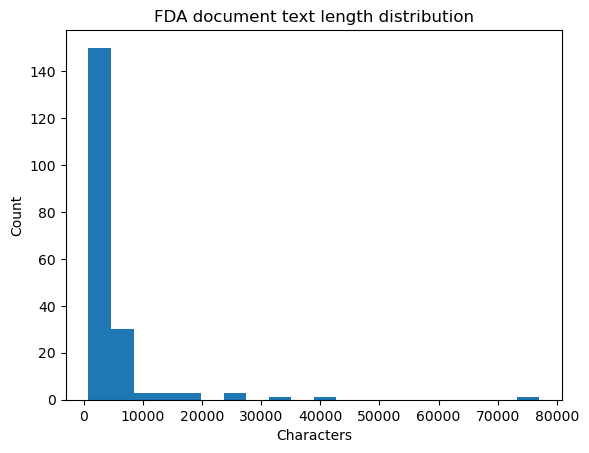

In [10]:
fda_df["text_len"] = fda_df["text"].astype(str).str.len()

plt.figure()
plt.hist(fda_df["text_len"], bins=20)
plt.title("FDA document text length distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [11]:
from collections import Counter

all_mentions = []
for m in fda_df["mentions"].dropna():
    all_mentions.extend(m)

counts = Counter(all_mentions)
top = counts.most_common(15)

top_df = pd.DataFrame(top, columns=["mention","count"])
top_df


,mention,count
0,BMS,9
1,J&J,3
2,Medtronic,3
3,Boston Scientific Corporation,3
4,Boston Scientific,3
5,CVS,3
6,Merck,1
7,Merck & Co,1
8,MDT,1


# Data Check (Yahoo Finance)

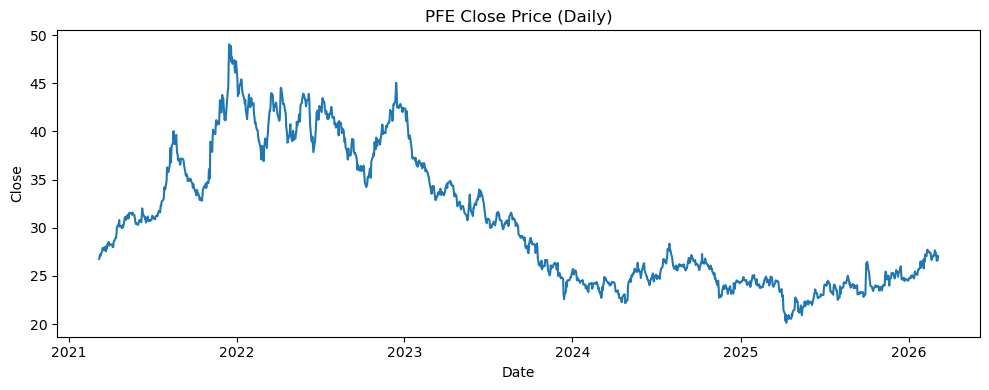

In [13]:
ticker = "PFE"
pfe_path = os.path.join(OUT_YF_DIR, f"{ticker}.csv")
pfe = pd.read_csv(pfe_path)

pfe["Date"] = pd.to_datetime(pfe["Date"], errors="coerce")
pfe["Close"] = pd.to_numeric(pfe["Close"], errors="coerce")

pfe = pfe.dropna(subset=["Date", "Close"]).sort_values("Date")

plt.figure(figsize=(10,4))
plt.plot(pfe["Date"], pfe["Close"])
plt.title(f"{ticker} Close Price (Daily)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.tight_layout()
plt.show()


# Data Check (GDELT)

In [14]:
import pandas as pd
import json

GDELT_FILE = "./data/news/gdelt_articles.jsonl"

records = []
with open(GDELT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

gdelt_df = pd.DataFrame(records)

print(gdelt_df.shape)
gdelt_df.head()

(273, 12)


,source,company,ticker,query,fetched_at,url,title,seendate,domain,language,sourcecountry,tone
0,GDELT,Johnson & Johnson,JNJ,"""Johnson & Johnson"" AND (health OR FDA OR drug...",2026-03-08T21:16:41.082282+00:00,https://www.fool.com/investing/2026/03/08/7-di...,These 7 Elite Dividend Stocks Pay $114 Billion...,20260308T191500Z,fool.com,English,United States,None
1,GDELT,Johnson & Johnson,JNJ,"""Johnson & Johnson"" AND (health OR FDA OR drug...",2026-03-08T21:16:41.082439+00:00,https://www.dailypolitical.com/2026/03/08/heal...,Healthcare Stocks To Add to Your Watchlist – M...,20260308T183000Z,dailypolitical.com,English,United States,None
2,GDELT,Johnson & Johnson,JNJ,"""Johnson & Johnson"" AND (health OR FDA OR drug...",2026-03-08T21:16:41.082504+00:00,https://www.yahoo.com/news/articles/inside-law...,Inside the Lawsuit That Could Reshape Social M...,20260308T181500Z,yahoo.com,English,United States,None
3,GDELT,Johnson & Johnson,JNJ,"""Johnson & Johnson"" AND (health OR FDA OR drug...",2026-03-08T21:16:41.082544+00:00,https://www.insidermonkey.com/blog/johnson-and...,Johnson and Johnson ( JNJ ) Reports Positive P...,20260308T173000Z,insidermonkey.com,English,United States,None
4,GDELT,Johnson & Johnson,JNJ,"""Johnson & Johnson"" AND (health OR FDA OR drug...",2026-03-08T21:16:41.082578+00:00,https://www.fool.com/investing/2026/03/08/2-no...,2 No - Brainer Dividend Stocks to Buy in 2026,20260308T173000Z,fool.com,English,United States,None


In [15]:
# Clean up
gdelt_df["seendate"] = pd.to_datetime(gdelt_df["seendate"], errors="coerce")
gdelt_df["date"] = gdelt_df["seendate"].dt.date
gdelt_df["tone"] = pd.to_numeric(gdelt_df["tone"], errors="coerce")

gdelt_df[["company", "title", "domain", "seendate", "tone"]].head()

,company,title,domain,seendate,tone
0,Johnson & Johnson,These 7 Elite Dividend Stocks Pay $114 Billion...,fool.com,2026-03-08 19:15:00+00:00,NaN
1,Johnson & Johnson,Healthcare Stocks To Add to Your Watchlist – M...,dailypolitical.com,2026-03-08 18:30:00+00:00,NaN
2,Johnson & Johnson,Inside the Lawsuit That Could Reshape Social M...,yahoo.com,2026-03-08 18:15:00+00:00,NaN
3,Johnson & Johnson,Johnson and Johnson ( JNJ ) Reports Positive P...,insidermonkey.com,2026-03-08 17:30:00+00:00,NaN
4,Johnson & Johnson,2 No - Brainer Dividend Stocks to Buy in 2026,fool.com,2026-03-08 17:30:00+00:00,NaN


# Articles per company

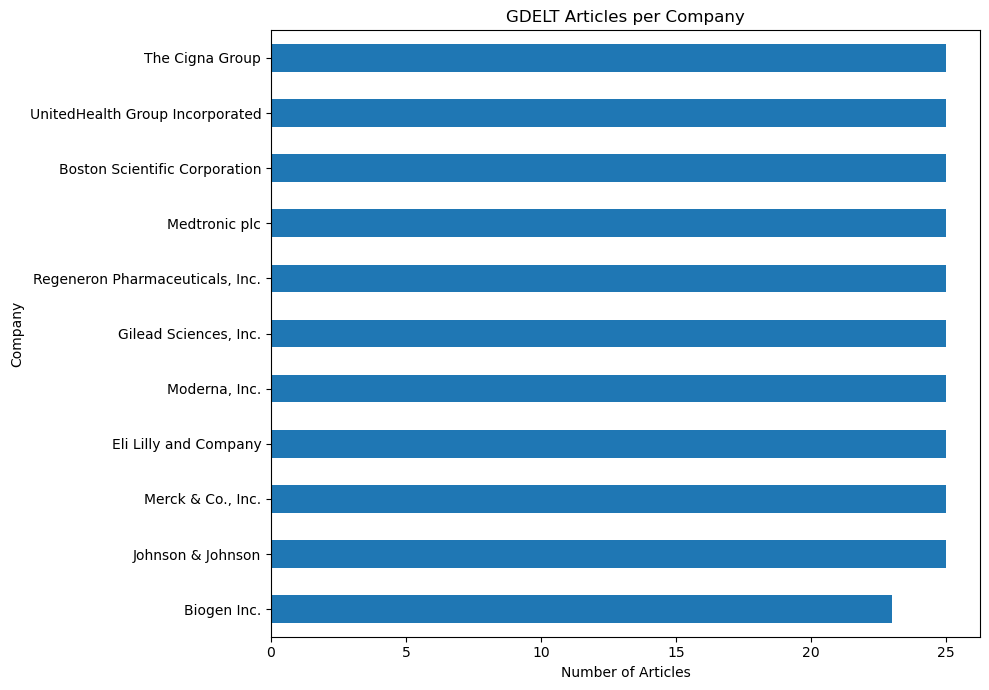

In [16]:
import matplotlib.pyplot as plt

company_counts = (
    gdelt_df["company"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
company_counts.plot(kind="barh")
plt.title("GDELT Articles per Company")
plt.xlabel("Number of Articles")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

# Top news domains

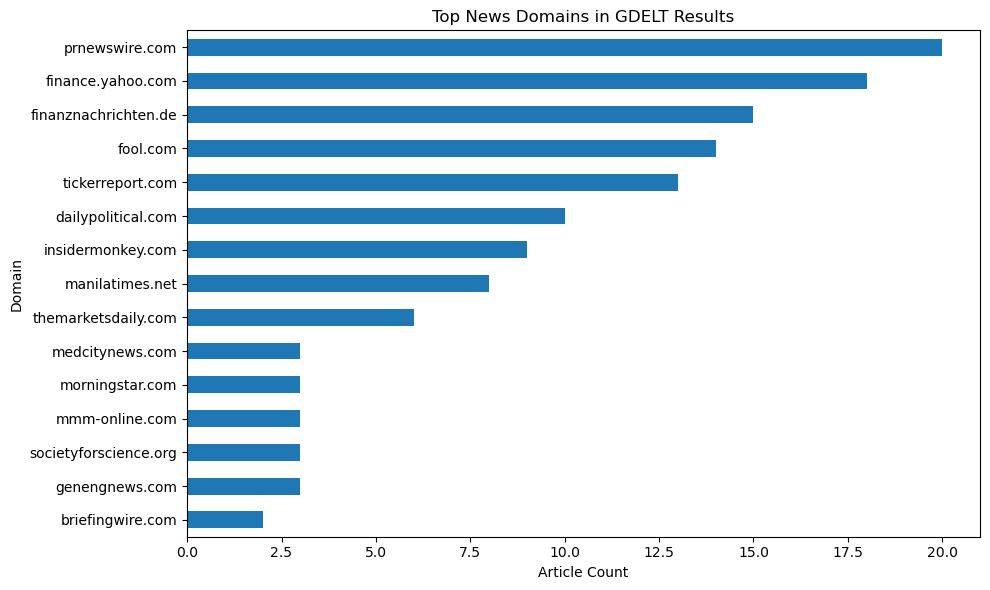

In [17]:
top_domains = (
    gdelt_df["domain"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
top_domains.plot(kind="barh")
plt.title("Top News Domains in GDELT Results")
plt.xlabel("Article Count")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()

# Articles over time

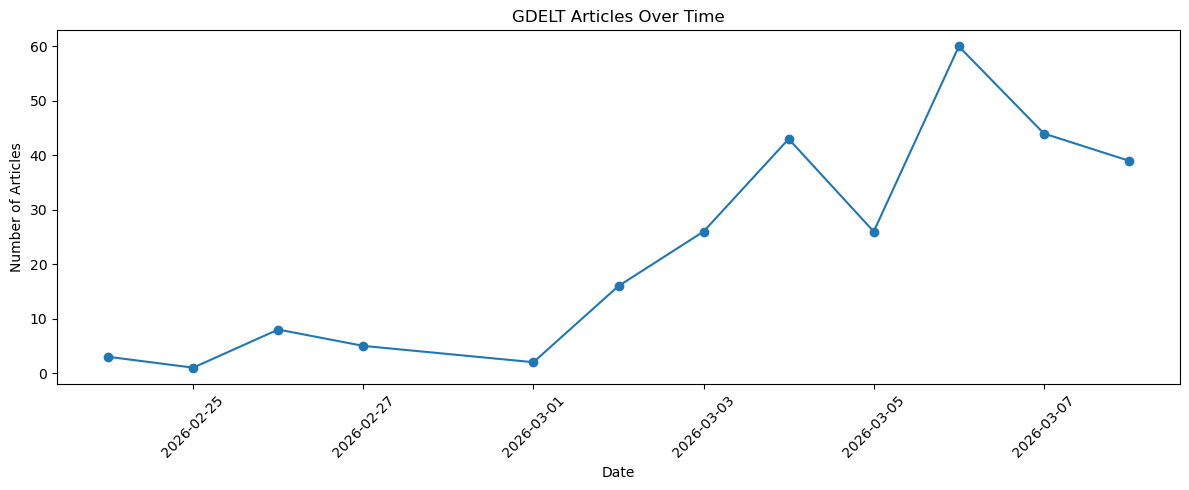

In [18]:
daily_counts = (
    gdelt_df.groupby("date")
    .size()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(daily_counts.index, daily_counts.values, marker="o")
plt.title("GDELT Articles Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()